# Looking at teenagers in the united states is there an asosiation between reaction time and ones age?
does a persons participation in a sport impact this? 
this is a observational study becuase not only is this a sample of the overall global population but it is a sample of that sample, IE we are only looking at a small group of teenagers.


In [1]:
import pandas as pd
df = pd.read_csv("CensusAtSchool.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    str    
 1   Region                            500 non-null    str    
 2   DataYear                          500 non-null    int64  
 3   ClassGrade                        500 non-null    int64  
 4   Gender                            497 non-null    str    
 5   Ageyears                          496 non-null    float64
 6   Handed                            492 non-null    str    
 7   Height_cm                         474 non-null    str    
 8   Footlength_cm                     459 non-null    str    
 9   Armspan_cm                        449 non-null    str    
 10  Languages_spoken                  489 non-null    str    
 11  Travel_to_School                  491 non-null    str    
 12  Travel_time_to_Scho

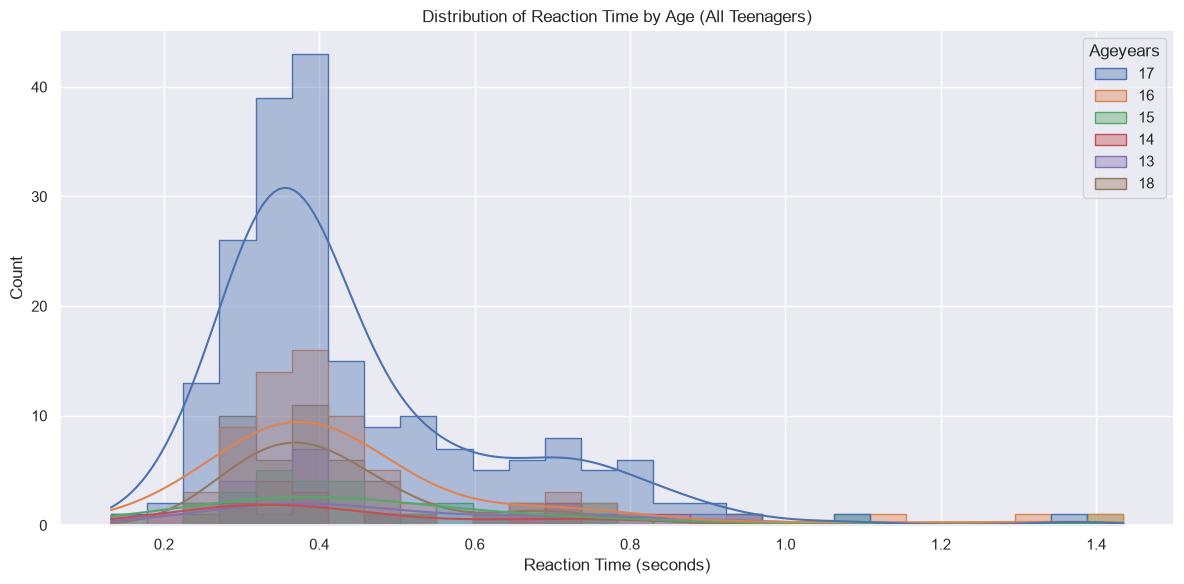

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
df = pd.read_csv("CensusAtSchool.csv")
sns.set_theme()

# 1. Clean and convert numeric columns
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
df["Ageyears"] = pd.to_numeric(df["Ageyears"], errors="coerce")

# 2. Filter for valid reaction times AND all teenagers (ages 13 to 18)
teens = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Ageyears"].between(13, 18))
].copy()

# Convert Ageyears to string so Seaborn treats each age as a distinct category
teens["Ageyears"] = teens["Ageyears"].astype(int).astype(str)

# 3. Plotting reaction time distribution for all teenagers
plt.figure(figsize=(12, 6))
sns.histplot(
    data=teens,
    x="Reaction_time",
    hue="Ageyears",
    kde=True,
    element="step",
    alpha=0.4,
)

plt.title("Distribution of Reaction Time by Age (All Teenagers)")
plt.xlabel("Reaction Time (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

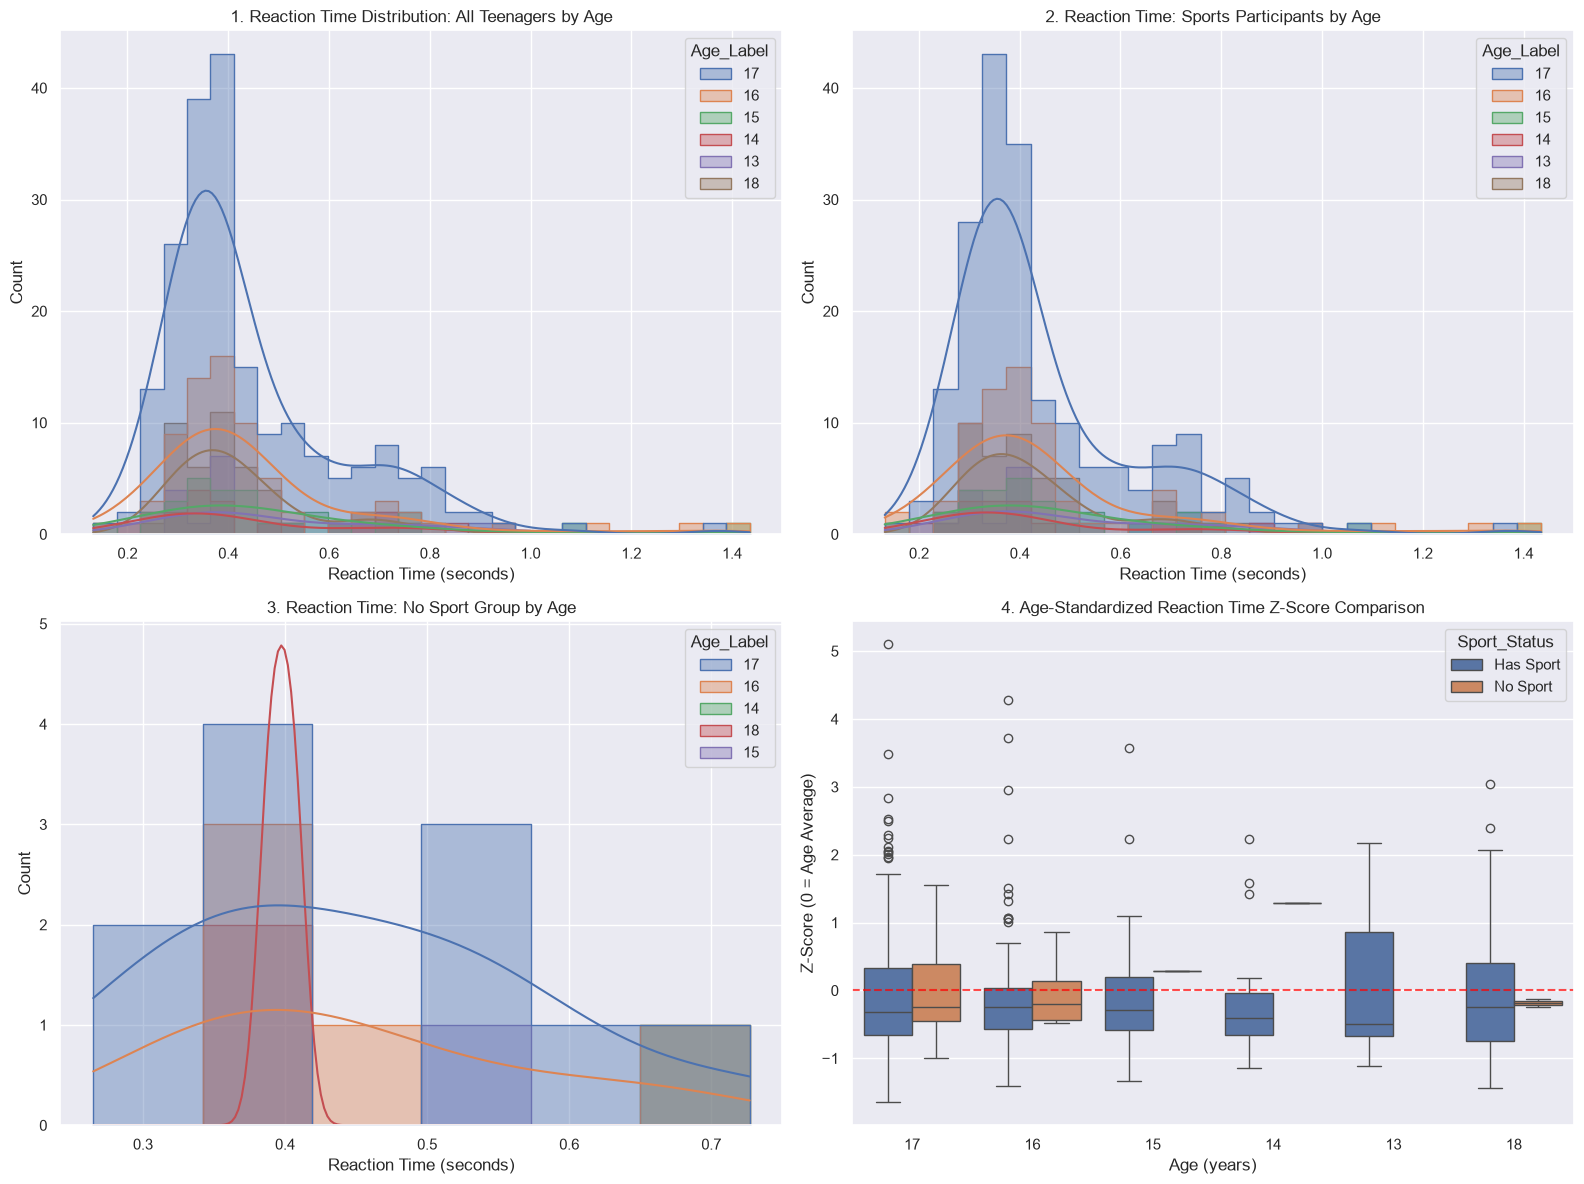

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. LOAD & CLEAN DATASET
# ==========================================
df = pd.read_csv("CensusAtSchool.csv")
sns.set_theme()

# Convert columns to numeric
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
df["Ageyears"] = pd.to_numeric(df["Ageyears"], errors="coerce")

# Filter for realistic reaction times (0.1s to 2.0s) and teenagers (ages 13 to 18)
teens = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Ageyears"].between(13, 18))
].copy()

# Categorize Sport participation status
has_no_sport = teens["Favourite_physical_activity"].str.contains(
    "none", case=False, na=True
)
teens["Sport_Status"] = np.where(has_no_sport, "No Sport", "Has Sport")

# Calculate Reaction Time Z-Score grouped by exact age
age_group = teens.groupby("Ageyears")["Reaction_time"]
teens["Reaction_time_Zscore"] = (
    teens["Reaction_time"] - age_group.transform("mean")
) / age_group.transform("std")

# Convert Ageyears to string for categorical hue plotting
teens["Age_Label"] = teens["Ageyears"].astype(int).astype(str)

# Create subsets for specific group plots
sports_only = teens[teens["Sport_Status"] == "Has Sport"]
no_sports_only = teens[teens["Sport_Status"] == "No Sport"]

# ==========================================
# 2. DASHBOARD PLOTTING (2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All Teenagers by Age
sns.histplot(
    data=teens,
    x="Reaction_time",
    hue="Age_Label",
    kde=True,
    element="step",
    alpha=0.4,
    ax=axes[0, 0],
)
axes[0, 0].set_title("1. Reaction Time Distribution: All Teenagers by Age")
axes[0, 0].set_xlabel("Reaction Time (seconds)")
axes[0, 0].set_ylabel("Count")

# Plot 2: Teenagers Participating in Sports by Age
sns.histplot(
    data=sports_only,
    x="Reaction_time",
    hue="Age_Label",
    kde=True,
    element="step",
    alpha=0.4,
    ax=axes[0, 1],
)
axes[0, 1].set_title("2. Reaction Time: Sports Participants by Age")
axes[0, 1].set_xlabel("Reaction Time (seconds)")
axes[0, 1].set_ylabel("Count")

# Plot 3: Teenagers with No Favorite Sport by Age
sns.histplot(
    data=no_sports_only,
    x="Reaction_time",
    hue="Age_Label",
    kde=True,
    element="step",
    alpha=0.4,
    ax=axes[1, 0],
)
axes[1, 0].set_title("3. Reaction Time: No Sport Group by Age")
axes[1, 0].set_xlabel("Reaction Time (seconds)")
axes[1, 0].set_ylabel("Count")

# Plot 4: Age-Standardized Z-Score (Sports vs. No Sports)
sns.boxplot(
    data=teens,
    x="Age_Label",
    y="Reaction_time_Zscore",
    hue="Sport_Status",
    ax=axes[1, 1],
)
axes[1, 1].axhline(0, color="red", linestyle="--", alpha=0.7, label="Age Mean")
axes[1, 1].set_title("4. Age-Standardized Reaction Time Z-Score Comparison")
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Z-Score (0 = Age Average)")

plt.tight_layout()
plt.show()

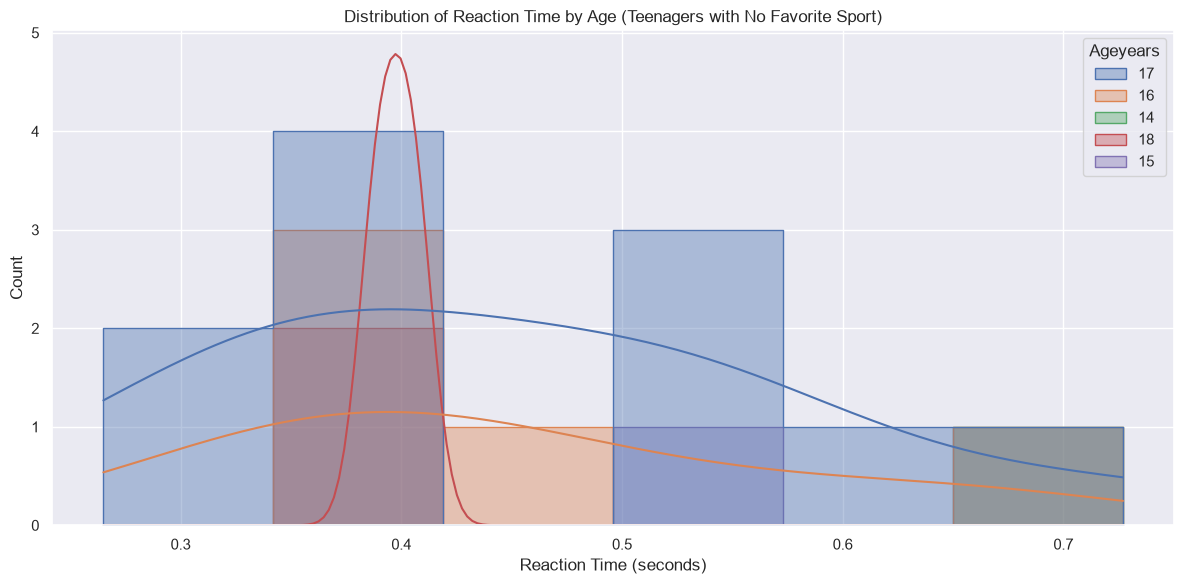

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
df = pd.read_csv("CensusAtSchool.csv")
sns.set_theme()

# 1. Clean and convert numeric columns
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
df["Ageyears"] = pd.to_numeric(df["Ageyears"], errors="coerce")

# 2. Keep ONLY rows where 'Favourite_physical_activity' contains "none" (or is missing)
no_sports = df[
    df["Favourite_physical_activity"].str.contains("none", case=False, na=True)
].copy()

# 3. Filter for valid reaction times AND filter for teenagers (ages 13 to 18)
no_sports = no_sports[
    (no_sports["Reaction_time"].between(0.1, 2.0))
    & (no_sports["Ageyears"].between(13, 18))
].copy()

# Convert Ageyears to string so Seaborn treats each age as a distinct group
no_sports["Ageyears"] = no_sports["Ageyears"].astype(int).astype(str)

# 4. Plotting reaction time distribution grouped by exact teenage age
plt.figure(figsize=(12, 6))
sns.histplot(
    data=no_sports,
    x="Reaction_time",
    hue="Ageyears",
    kde=True,
    element="step",
    alpha=0.4,
)

plt.title("Distribution of Reaction Time by Age (Teenagers with No Favorite Sport)")
plt.xlabel("Reaction Time (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

GLOBAL TEENAGER BASELINE (Mean = 0.450 s, Std Dev = 0.196 s)

--- Z-SCORE SUMMARY DATAFRAME ---
                        Count  Mean_Reaction_Time_Sec  Mean_Global_Zscore
Age_Label Sport_Status                                                   
13        Has Sport        21                   0.507               0.291
14        Has Sport        16                   0.414              -0.185
          No Sport          1                   0.675               1.150
15        Has Sport        28                   0.485               0.177
          No Sport          1                   0.564               0.583
16        Has Sport        69                   0.456               0.028
          No Sport          5                   0.450               0.001
17        Has Sport       191                   0.445              -0.027
          No Sport         11                   0.450              -0.001
18        Has Sport        43                   0.423              -0.140
          No Spo

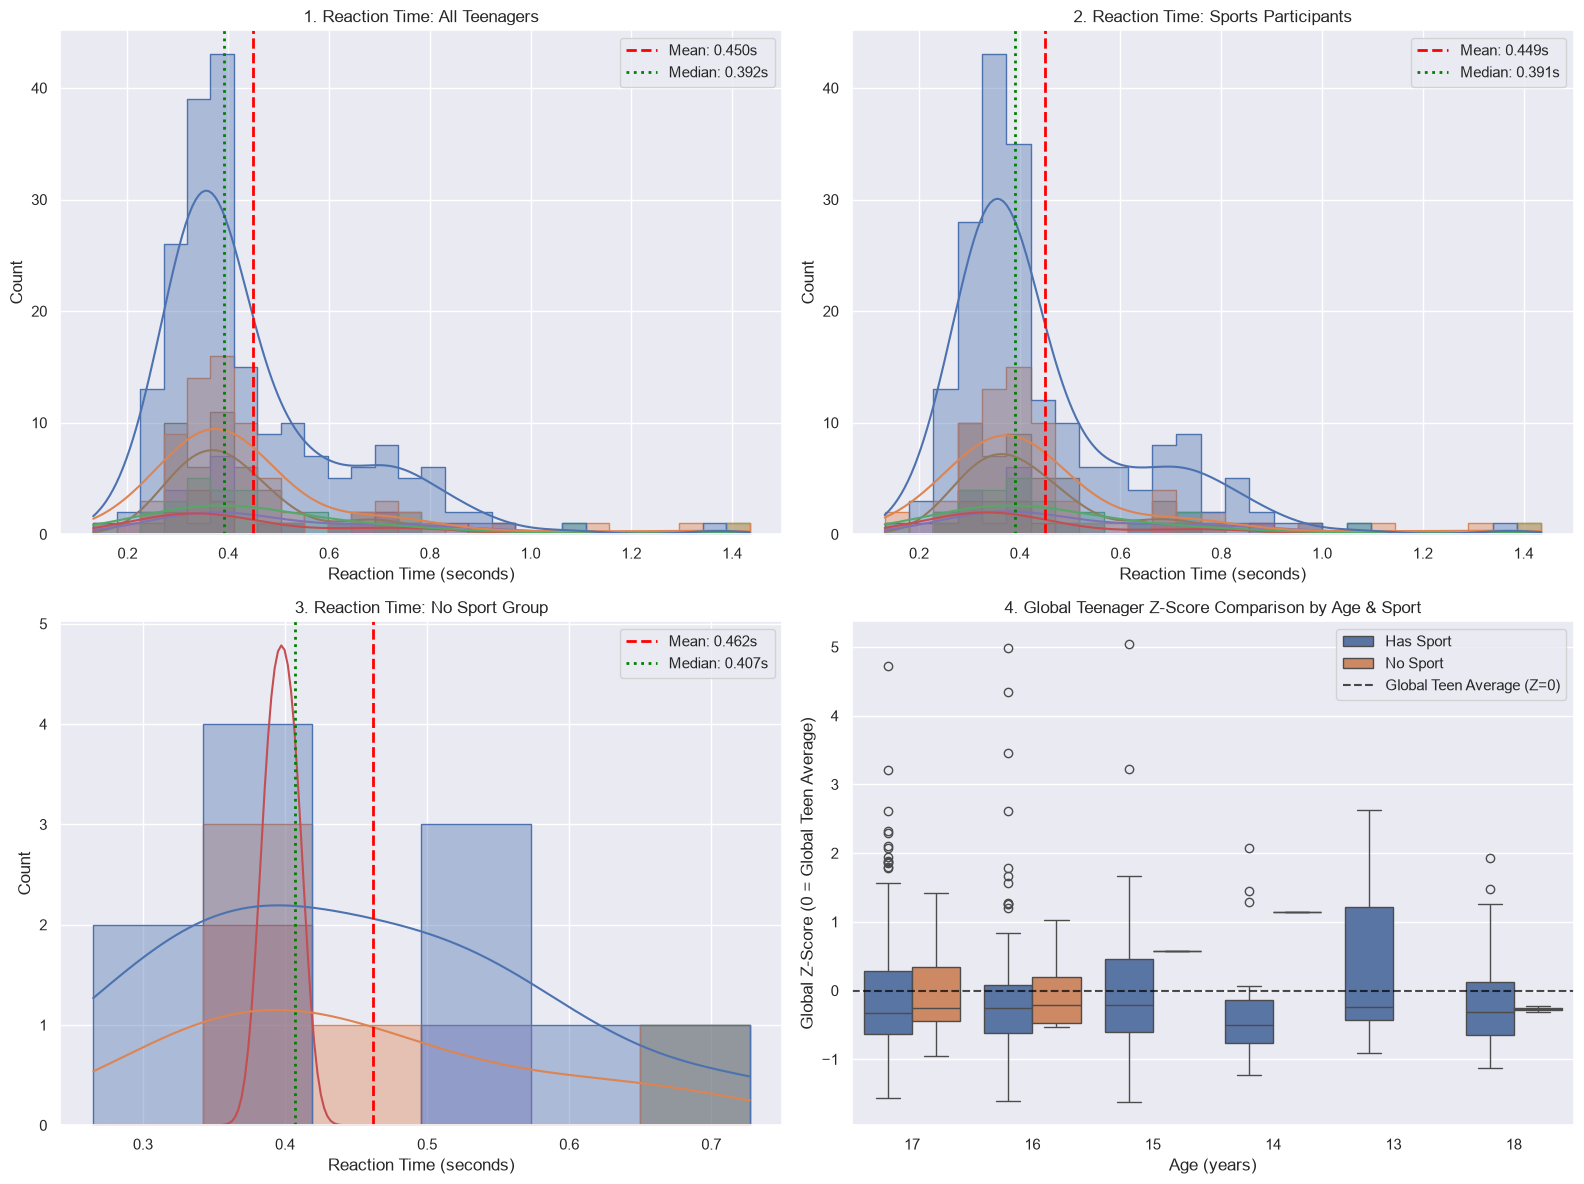

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. LOAD & CLEAN DATASET
# ==========================================
df = pd.read_csv("CensusAtSchool.csv")
sns.set_theme()

# Convert key columns to numeric
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
df["Ageyears"] = pd.to_numeric(df["Ageyears"], errors="coerce")

# Filter for realistic reaction times (0.1s to 2.0s) and ALL teenagers (ages 13 to 18)
teens = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Ageyears"].between(13, 18))
].copy()

# Categorize Sport participation status ('Has Sport' vs 'No Sport')
has_no_sport = teens["Favourite_physical_activity"].str.contains(
    "none", case=False, na=True
)
teens["Sport_Status"] = np.where(has_no_sport, "No Sport", "Has Sport")

# ==========================================
# 2. GLOBAL Z-SCORE CALCULATION (MEAN ONLY)
# ==========================================
global_mean = teens["Reaction_time"].mean()
global_std = teens["Reaction_time"].std()

# Z-Score calculated strictly from the global mean
teens["Global_Zscore"] = (teens["Reaction_time"] - global_mean) / global_std
teens["Age_Label"] = teens["Ageyears"].astype(int).astype(str)

# Subsets for individual group plots
sports_only = teens[teens["Sport_Status"] == "Has Sport"]
no_sports_only = teens[teens["Sport_Status"] == "No Sport"]

# ==========================================
# 3. SINGLE Z-SCORE SUMMARY DATAFRAME
# ==========================================
print("=" * 70)
print(f"GLOBAL TEENAGER BASELINE (Mean = {global_mean:.3f} s, Std Dev = {global_std:.3f} s)")
print("=" * 70)

# One single summary DataFrame grouping by Age & Sport Status
zscore_df = teens.groupby(["Age_Label", "Sport_Status"]).agg(
    Count=("Reaction_time", "count"),
    Mean_Reaction_Time_Sec=("Reaction_time", "mean"),
    Mean_Global_Zscore=("Global_Zscore", "mean")
).round(3)

print("\n--- Z-SCORE SUMMARY DATAFRAME ---")
print(zscore_df.to_string())
print("=" * 70)

# ==========================================
# 4. DASHBOARD PLOTTING (2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: All Teenagers by Age ---
mean_all = teens["Reaction_time"].mean()
med_all = teens["Reaction_time"].median()

sns.histplot(
    data=teens, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[0, 0]
)
axes[0, 0].axvline(mean_all, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_all:.3f}s")
axes[0, 0].axvline(med_all, color="green", linestyle=":", linewidth=2, label=f"Median: {med_all:.3f}s")
axes[0, 0].set_title("1. Reaction Time: All Teenagers")
axes[0, 0].set_xlabel("Reaction Time (seconds)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# --- Plot 2: Sports Participants by Age ---
mean_sports = sports_only["Reaction_time"].mean()
med_sports = sports_only["Reaction_time"].median()

sns.histplot(
    data=sports_only, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[0, 1]
)
axes[0, 1].axvline(mean_sports, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_sports:.3f}s")
axes[0, 1].axvline(med_sports, color="green", linestyle=":", linewidth=2, label=f"Median: {med_sports:.3f}s")
axes[0, 1].set_title("2. Reaction Time: Sports Participants")
axes[0, 1].set_xlabel("Reaction Time (seconds)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# --- Plot 3: No Sport Group by Age ---
mean_nosports = no_sports_only["Reaction_time"].mean()
med_nosports = no_sports_only["Reaction_time"].median()

sns.histplot(
    data=no_sports_only, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[1, 0]
)
axes[1, 0].axvline(mean_nosports, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_nosports:.3f}s")
axes[1, 0].axvline(med_nosports, color="green", linestyle=":", linewidth=2, label=f"Median: {med_nosports:.3f}s")
axes[1, 0].set_title("3. Reaction Time: No Sport Group")
axes[1, 0].set_xlabel("Reaction Time (seconds)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# --- Plot 4: Global Z-Score Boxplot (Sports vs No Sports across Ages) ---
sns.boxplot(
    data=teens, x="Age_Label", y="Global_Zscore", hue="Sport_Status", ax=axes[1, 1]
)
axes[1, 1].axhline(0, color="black", linestyle="--", alpha=0.7, label="Global Teen Average (Z=0)")
axes[1, 1].set_title("4. Global Teenager Z-Score Comparison by Age & Sport")
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Global Z-Score (0 = Global Teen Average)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# conclusion (rephrased by ai)
Based on the dataset analysis, two primary factors significantly influence reaction times among teenagers: sports participation and age progression.

Impact of Sports Participation:
Teenagers who participate in sports make up the vast majority of the sample. As a result, their average reaction time closely mirrors the global teenager baseline, with a Z-score near zero. In contrast, non-participants demonstrate a noticeably slower average reaction time, roughly zero point zero one seconds slower than the global mean. In tasks measured in tenths of a second, this represents a meaningful delay. These findings suggest that engaging in physical activity or structured sports is associated with faster Reaction times.

Impact of Age Progression:
Reaction times show a clear age-related trend, sharpening progressively as teenagers mature. Younger age groups exhibit positive Z-scores, meaning they are slower than the global average. Older teenagers, particularly ages seventeen and eighteen, consistently achieve negative Z-scores, indicating faster-than-average processing speeds.

Analytical Summary:
While sports participation provides an observable advantage in reaction speed across all cohorts, age remains the powerful compounding variable. Overall processing and reaction speed improves significantly from age thirteen through eighteen, likely driven by ongoing cognitive and physical maturation alongside athletic involvement.